In [498]:
# Import relevant packages 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates


from sklearn.impute import SimpleImputer  ## To impute missing values
plt.style.use("fivethirtyeight")


import warnings
warnings.filterwarnings("ignore")

### Load The Dataset

In [499]:
df = pd.read_csv("bitcoin_data/raw/btc_3h.csv")

In [500]:
df.head()

,datetime,open,high,low,close,volume
0,2020-01-01 00:00:00,7195.24,7244.87,7175.46,7242.85,2050.024313
1,2020-01-01 03:00:00,7242.66,7245.00,7215.03,7224.21,1596.208041
2,2020-01-01 06:00:00,7224.24,7236.27,7180.00,7200.64,2164.357851
3,2020-01-01 09:00:00,7200.29,7237.73,7185.20,7197.20,2251.108387
4,2020-01-01 12:00:00,7197.20,7234.97,7196.15,7221.43,2098.648667


In [501]:
print("\nMissing Values:") 
print(df.isnull().sum())


Missing Values:
datetime    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64


In [502]:
print("\nDuplicate Rows:") 
print(df.duplicated().sum())


Duplicate Rows:
0


In [503]:
df.describe()

,open,high,low,close,volume
count,18661.000000,18661.000000,18661.000000,18661.000000,18661.000000
mean,48925.458221,49259.049420,48572.490390,48929.248827,8828.941012
std,31316.689593,31468.485881,31153.400473,31315.910379,12200.516003
min,4565.630000,4918.140000,3782.130000,4565.590000,101.886500
25%,23066.940000,23220.000000,22890.520000,23074.160000,2525.129040
50%,42324.950000,42654.640000,41966.020000,42331.990000,4885.340620
75%,68217.940000,68644.000000,67763.640000,68219.970000,9648.799641
max,125284.010000,126199.630000,125032.010000,125284.000000,222031.582330


### Create Log Returns

In [504]:
df["log_return"] = np.log( df["close"] / df["close"].shift(1))

In [505]:
df

,datetime,open,high,low,close,volume,log_return
0,2020-01-01 00:00:00,7195.24,7244.87,7175.46,7242.85,2050.024313,NaN
1,2020-01-01 03:00:00,7242.66,7245.00,7215.03,7224.21,1596.208041,-0.002577
2,2020-01-01 06:00:00,7224.24,7236.27,7180.00,7200.64,2164.357851,-0.003268
3,2020-01-01 09:00:00,7200.29,7237.73,7185.20,7197.20,2251.108387,-0.000478
4,2020-01-01 12:00:00,7197.20,7234.97,7196.15,7221.43,2098.648667,0.003361
...,...,...,...,...,...,...,...
18656,2026-05-21 09:00:00,77924.63,77977.53,77147.15,77189.10,1441.400320,-0.009484
18657,2026-05-21 12:00:00,77189.10,77363.32,76719.47,76984.61,1942.799910,-0.002653
18658,2026-05-21 15:00:00,76984.61,78098.16,76900.00,77869.38,2107.403020,0.011427
18659,2026-05-21 18:00:00,77869.38,77922.01,77230.00,77705.81,1141.781970,-0.002103


In [506]:
### Log Volume
df["log_volume"] = np.log(df["volume"] + 1)

In [507]:
df = df.dropna()

In [508]:
print("\nLog Return Statistics:") 
print(df["log_return"].describe())


Log Return Statistics:
count    18660.000000
mean         0.000127
std          0.011085
min         -0.195588
25%         -0.003974
50%          0.000136
75%          0.004307
max          0.100377
Name: log_return, dtype: float64


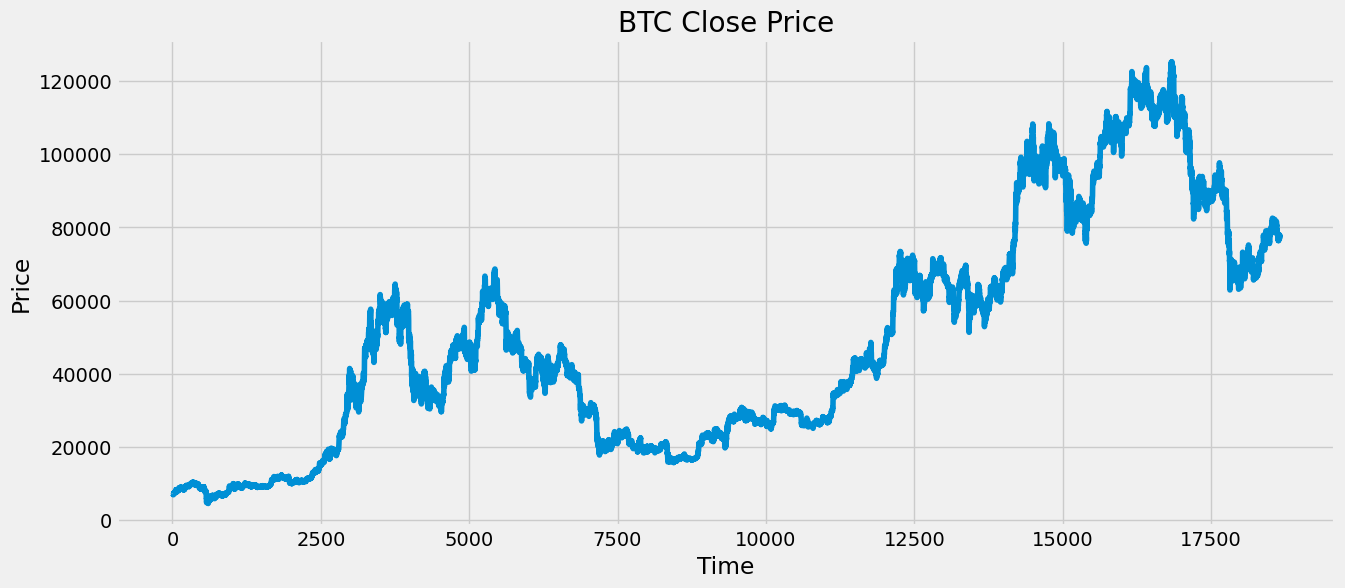

In [509]:
plt.figure(figsize=(14,6)) 
plt.plot(df["close"]) 
plt.title("BTC Close Price") 
plt.xlabel("Time") 
plt.ylabel("Price") 
plt.show()

### LOG RETURN VISUALIZATION

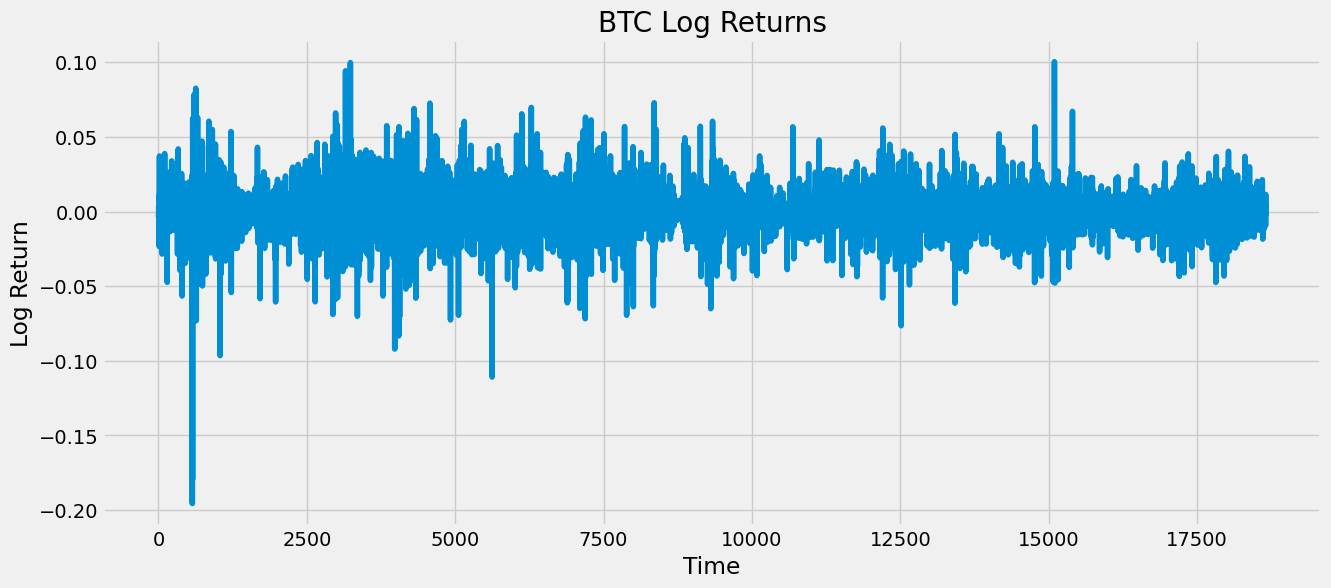

In [510]:
plt.figure(figsize=(14,6)) 
plt.plot(df["log_return"]) 
plt.title("BTC Log Returns") 
plt.xlabel("Time") 
plt.ylabel("Log Return") 
plt.show()

##### LOG RETURN HISTOGRAM

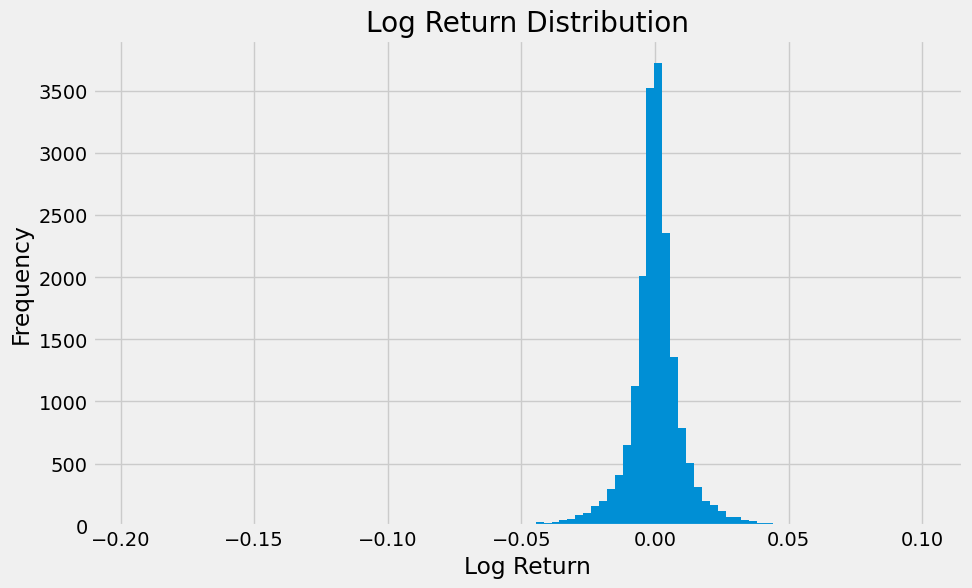

In [511]:
plt.figure(figsize=(10,6)) 
plt.hist(df["log_return"], bins=100) 
plt.title("Log Return Distribution") 
plt.xlabel("Log Return") 
plt.ylabel("Frequency") 
plt.show()

##### Volume Visualization

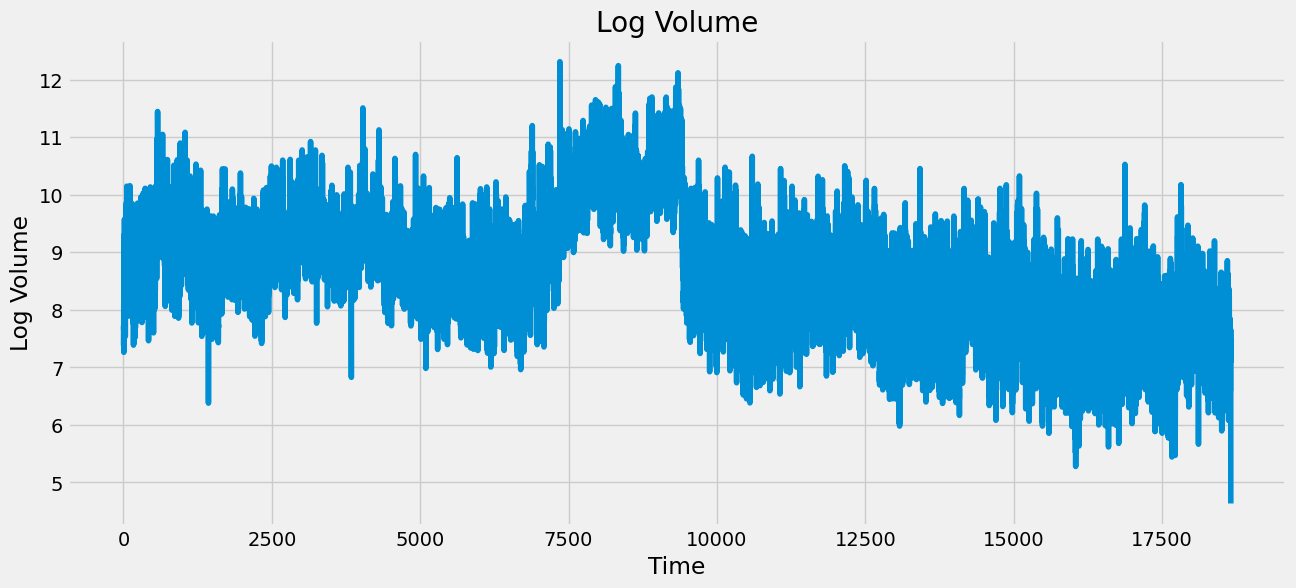

In [512]:
plt.figure(figsize=(14,6)) 
plt.plot(df["log_volume"]) 
plt.title("Log Volume") 
plt.xlabel("Time") 
plt.ylabel("Log Volume") 
plt.show()

##### ROLLING VOLATILITY

In [513]:
df["volatility_20"] = ( df["log_return"].rolling(20).std() )

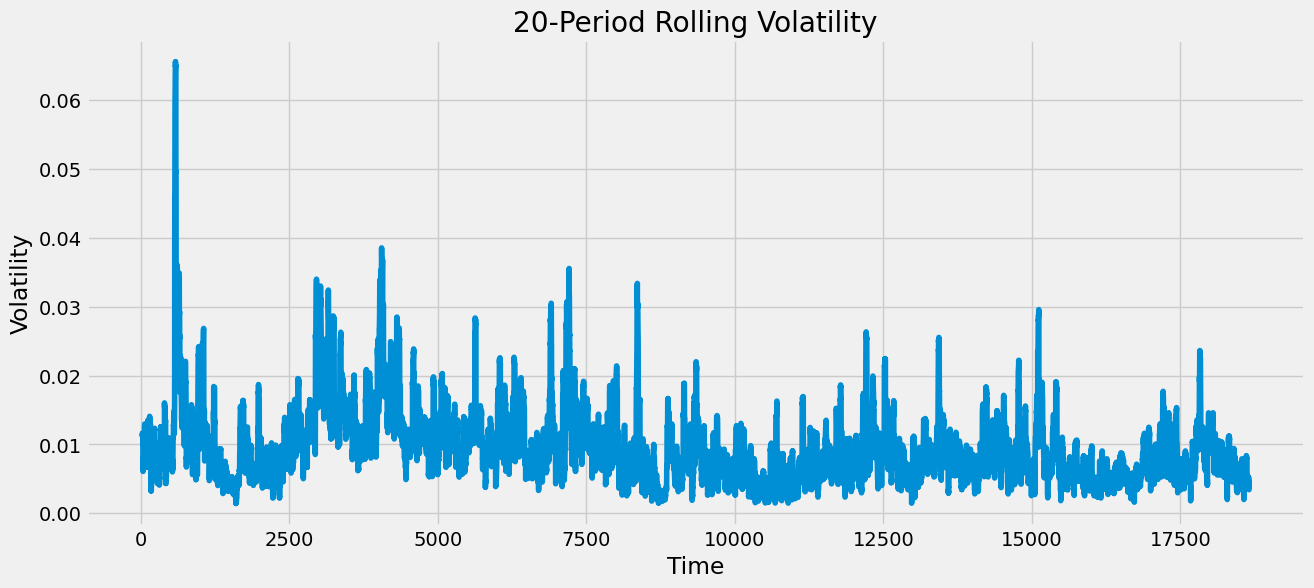

In [514]:
plt.figure(figsize=(14,6)) 
plt.plot(df["volatility_20"]) 
plt.title("20-Period Rolling Volatility") 
plt.xlabel("Time") 
plt.ylabel("Volatility") 
plt.show()

### Candle Range

In [515]:
df["range_pct"] = ( (df["high"] - df["low"]) / df["open"] )

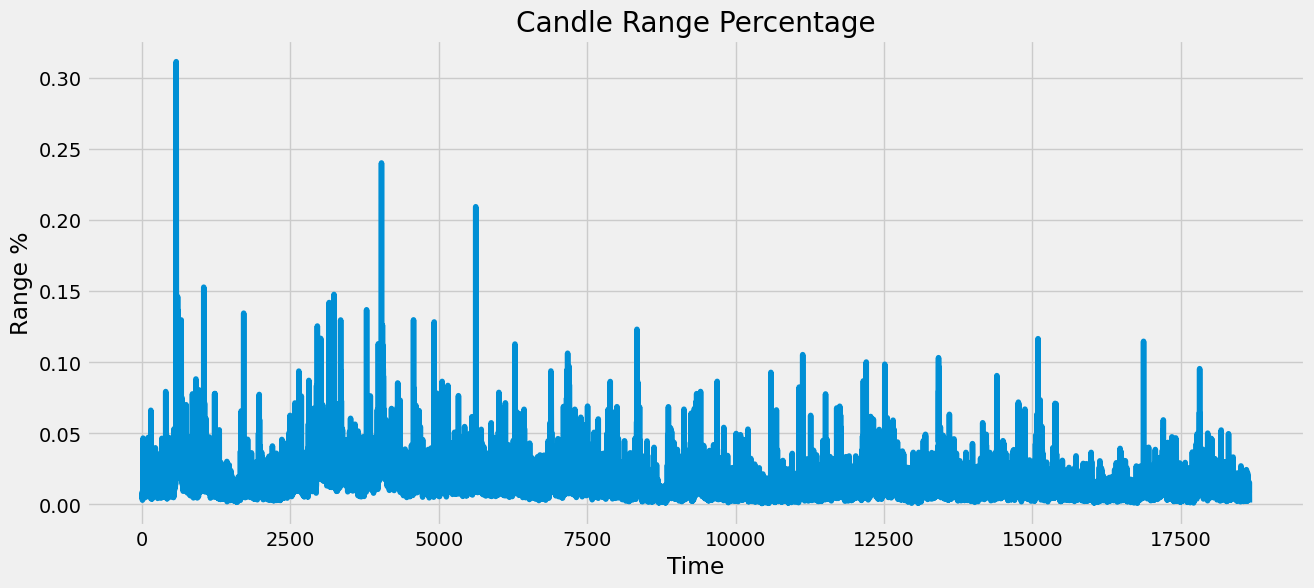

In [516]:
plt.figure(figsize=(14,6)) 
plt.plot(df["range_pct"]) 
plt.title("Candle Range Percentage") 
plt.xlabel("Time") 
plt.ylabel("Range %") 
plt.show()

##### VOLUME VS RETURN

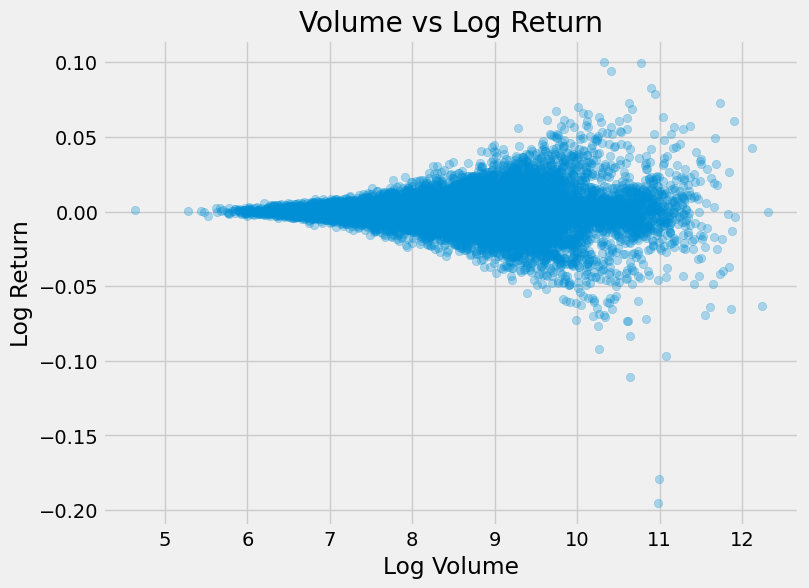

In [517]:
plt.figure(figsize=(8,6)) 
plt.scatter( df["log_volume"], df["log_return"], alpha=0.3 ) 
plt.title("Volume vs Log Return") 
plt.xlabel("Log Volume") 
plt.ylabel("Log Return") 
plt.show()

##### AUTOCORRELATION

In [518]:
autocorr = df["log_return"].autocorr() 
print("\nLog Return Autocorrelation:") 
print(autocorr)


Log Return Autocorrelation:
-0.009624684827872956


##### ABSOLUTE RETURN AUTOCORRELATION

In [519]:
vol_autocorr = ( np.abs(df["log_return"]).autocorr() ) 
print("\nVolatility Autocorrelation:") 
print(vol_autocorr)


Volatility Autocorrelation:
0.2455368800856972


### Outliers

In [520]:
q1 = df["log_return"].quantile(0.25) 
q3 = df["log_return"].quantile(0.75) 
iqr = q3 - q1 
lower = q1 - 1.5 * iqr 
upper = q3 + 1.5 * iqr 
outliers = df[ (df["log_return"] < lower) | (df["log_return"] > upper) ]
print("\nOutlier Count:") 
print(len(outliers))


Outlier Count:
1828


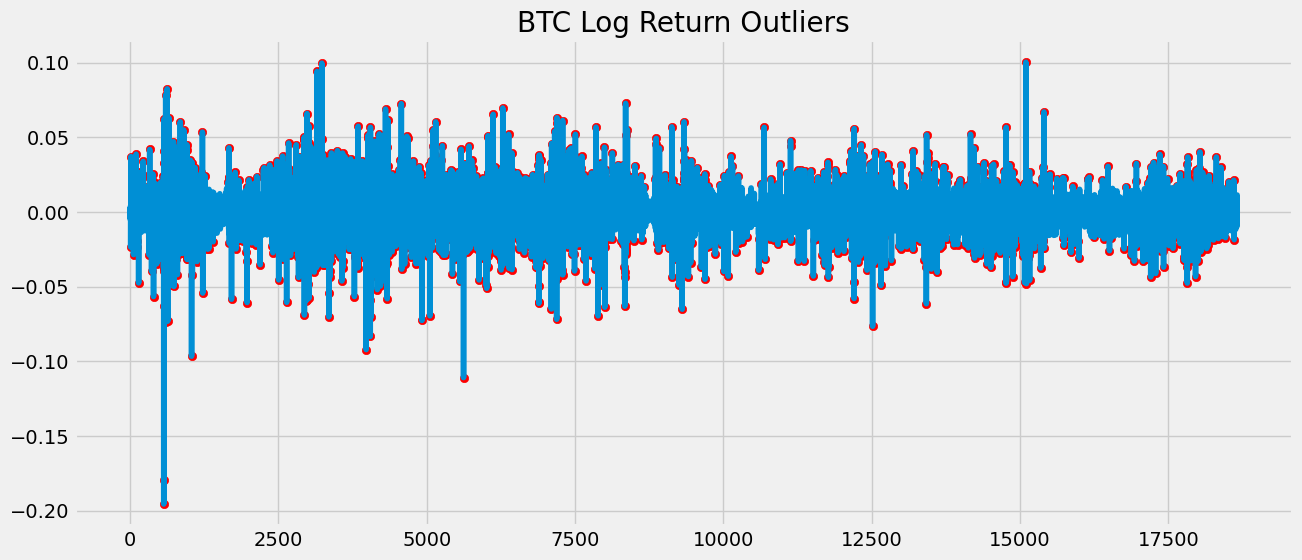

In [521]:
plt.figure(figsize=(14,6))

plt.plot(df["log_return"])

plt.scatter(
    outliers.index,
    outliers["log_return"],
    color="red"
)

plt.title("BTC Log Return Outliers")

plt.show()

In [524]:
print("\nFinal Shape:") 
print(df.shape)


Final Shape:
(18660, 10)


In [525]:
df["datetime"] = pd.to_datetime(df["datetime"]) 
df = df.sort_values("datetime") 
df = df.set_index("datetime")

### Feature Engineering

In [526]:
### Multi-Period Returns
df["ret_1"] = df["log_return"] 
df["ret_2"] = np.log( df["close"] / df["close"].shift(2) ) 
df["ret_4"] = np.log( df["close"] / df["close"].shift(4) ) 
df["ret_8"] = np.log( df["close"] / df["close"].shift(8) )

In [527]:
### Volume Return
df["volume_return"] = np.log( df["volume"] / df["volume"].shift(1) )

In [528]:
### Volume Ratio
df["volume_ma_20"] = ( df["volume"] .rolling(20) .mean() ) 
df["volume_ratio"] = ( df["volume"] / df["volume_ma_20"] )

In [529]:
### Volatility_10
df["volatility_10"] = ( df["log_return"] .rolling(10) .std() )

In [530]:
### Candle Body
df["body_size"] = ( (df["close"] - df["open"]) / df["open"] )

In [531]:
### Upper WICK
df["upper_wick"] = ( ( df["high"] - np.maximum( df["open"], df["close"] ) ) / df["open"] )

In [532]:
### LOWER WICK
df["lower_wick"] = ( ( np.minimum( df["open"], df["close"] ) - df["low"] ) / df["open"] )

In [533]:
### Candle Range
df["range_pct"] = ( (df["high"] - df["low"]) / df["open"] )

In [534]:
### EMA Features
df["ema_20"] = ( df["close"] .ewm(span=20) .mean() ) 
df["ema_50"] = ( df["close"] .ewm(span=50) .mean() ) 
df["ema_200"] = ( df["close"] .ewm(span=200) .mean() )

In [535]:
### EMA Ratios
df["ema20_ratio"] = ( df["close"] / df["ema_20"] ) 
df["ema50_ratio"] = ( df["close"] / df["ema_50"] ) 
df["ema200_ratio"] = ( df["close"] / df["ema_200"] )

In [536]:
### EMA Slopes
df["ema20_slope"] = ( df["ema_20"] .pct_change() ) 
df["ema50_slope"] = ( df["ema_50"] .pct_change() )

##### RSI

In [537]:
def calculate_rsi(data, period=14, price_col="close"):
    delta = data[price_col].diff()

    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    # Wilder's smoothing method
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi


In [538]:
df["RSI_7"] = calculate_rsi(df, period=7)
df["RSI_14"] = calculate_rsi(df, period=14)
df["RSI_21"] = calculate_rsi(df, period=21)

In [539]:
#### MACD
ema12 = df["close"].ewm(span=12).mean() 
ema26 = df["close"].ewm(span=26).mean() 
df["macd"] = ema12 - ema26 
df["macd_signal"] = ( df["macd"] .ewm(span=9) .mean() )

In [540]:
df["macd_histogram"] = ( df["macd"] - df["macd_signal"] )

##### SMA

In [541]:
df["SMA_7"] = df["close"].rolling(window=7).mean()
df["SMA_20"] = df["close"].rolling(window=20).mean()
df["SMA_50"] = df["close"].rolling(window=50).mean()
df["SMA_100"] = df["close"].rolling(window=100).mean()
df["SMA_200"] = df["close"].rolling(window=200).mean()

In [542]:
df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'log_return', 'log_volume',
       'volatility_20', 'range_pct', 'ret_1', 'ret_2', 'ret_4', 'ret_8',
       'volume_return', 'volume_ma_20', 'volume_ratio', 'volatility_10',
       'body_size', 'upper_wick', 'lower_wick', 'ema_20', 'ema_50', 'ema_200',
       'ema20_ratio', 'ema50_ratio', 'ema200_ratio', 'ema20_slope',
       'ema50_slope', 'RSI_7', 'RSI_14', 'RSI_21', 'macd', 'macd_signal',
       'macd_histogram', 'SMA_7', 'SMA_20', 'SMA_50', 'SMA_100', 'SMA_200'],
      dtype='str')

### Correlation Matrix

In [573]:
# Make sure target_3h exists
print(df.columns)

# Correlation of all numeric features with target_3h
corr_with_target = (
    df.corr(numeric_only=True)["target_3h"]
    .drop("target_3h")
    .sort_values(ascending=False)
)

print("Correlation with target_3h:")
print(corr_with_target)

Index(['open', 'high', 'low', 'close', 'volume', 'log_return', 'log_volume',
       'volatility_20', 'range_pct', 'ret_1', 'ret_2', 'ret_4', 'ret_8',
       'volume_return', 'volume_ma_20', 'volume_ratio', 'volatility_10',
       'body_size', 'upper_wick', 'lower_wick', 'ema_20', 'ema_50', 'ema_200',
       'ema20_ratio', 'ema50_ratio', 'ema200_ratio', 'ema20_slope',
       'ema50_slope', 'RSI_7', 'RSI_14', 'RSI_21', 'macd', 'macd_signal',
       'macd_histogram', 'SMA_7', 'SMA_20', 'SMA_50', 'SMA_100', 'SMA_200',
       'target_3h'],
      dtype='str')
Correlation with target_3h:
range_pct         0.019910
ret_4             0.016541
lower_wick        0.015928
RSI_21            0.013381
RSI_14            0.011948
volume_ratio      0.011446
volume            0.010545
log_volume        0.010191
upper_wick        0.008728
RSI_7             0.008562
ema200_ratio      0.008484
volume_return     0.008106
volatility_10     0.007718
volatility_20     0.004757
volume_ma_20      0.004519
ema50_s

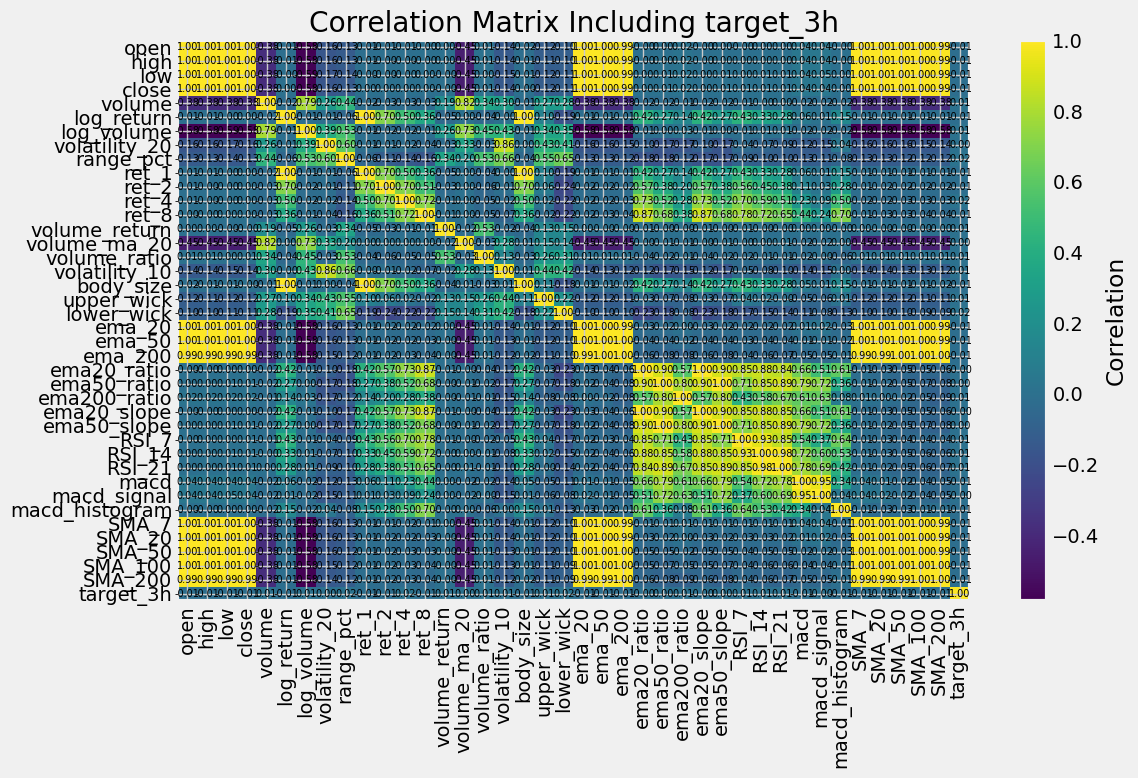

In [575]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=7)

plt.title("Correlation Matrix Including target_3h")
plt.tight_layout()
plt.show()

In [576]:
corr = df.corr(numeric_only=True)
corr

,open,high,low,close,volume,log_return,log_volume,volatility_20,range_pct,ret_1,...,RSI_21,macd,macd_signal,macd_histogram,SMA_7,SMA_20,SMA_50,SMA_100,SMA_200,target_3h
open,1.000000,0.999913,0.999877,0.999845,-0.380735,-0.013810,-0.580605,-0.163182,-0.132907,-0.013810,...,0.002416,0.041144,0.044375,-0.002093,0.999827,0.999250,0.997892,0.995551,0.990635,-0.013576
high,0.999913,1.000000,0.999818,0.999918,-0.378700,-0.006093,-0.576818,-0.159285,-0.126514,-0.006093,...,0.004210,0.040777,0.043572,-0.000801,0.999774,0.999208,0.997877,0.995571,0.990667,-0.013639
low,0.999877,0.999818,1.000000,0.999905,-0.383724,-0.004929,-0.585557,-0.167639,-0.141933,-0.004929,...,0.006201,0.043346,0.045675,0.001150,0.999699,0.999068,0.997665,0.995298,0.990386,-0.013769
close,0.999845,0.999918,0.999905,1.000000,-0.381039,0.001037,-0.580972,-0.163156,-0.133604,0.001037,...,0.006834,0.042224,0.044525,0.001019,0.999721,0.999125,0.997759,0.995413,0.990491,-0.013820
volume,-0.380735,-0.378700,-0.383724,-0.381039,1.000000,-0.017845,0.791418,0.255169,0.439226,-0.017845,...,0.001649,-0.021699,-0.016860,-0.019314,-0.380407,-0.379917,-0.379481,-0.378896,-0.378603,0.010545
log_return,-0.013810,-0.006093,-0.004929,0.001037,-0.017845,1.000000,-0.013433,-0.005577,-0.057731,1.000000,...,0.278353,0.056089,0.010329,0.153705,-0.011591,-0.012601,-0.013104,-0.013436,-0.013796,-0.010122
log_volume,-0.580605,-0.576818,-0.585557,-0.580972,0.791418,-0.013433,1.000000,0.387206,0.534527,-0.013433,...,0.011905,-0.023690,-0.017972,-0.022447,-0.580301,-0.579724,-0.579321,-0.579253,-0.581151,0.010191
volatility_20,-0.163182,-0.159285,-0.167639,-0.163156,0.255169,-0.005577,0.387206,1.000000,0.603009,-0.005577,...,-0.093905,-0.124035,-0.145257,0.042142,-0.163036,-0.161379,-0.155450,-0.147818,-0.142388,0.004757
range_pct,-0.132907,-0.126514,-0.141933,-0.133604,0.439226,-0.057731,0.534527,0.603009,1.000000,-0.057731,...,-0.104349,-0.126241,-0.109516,-0.076713,-0.131120,-0.128151,-0.124309,-0.120396,-0.118611,0.019910
ret_1,-0.013810,-0.006093,-0.004929,0.001037,-0.017845,1.000000,-0.013433,-0.005577,-0.057731,1.000000,...,0.278353,0.056089,0.010329,0.153705,-0.011591,-0.012601,-0.013104,-0.013436,-0.013796,-0.010122


### Future Target 3H

In [543]:
df["target_3h"] = np.log(df["close"].shift(-1) / df["close"])

### Features List

In [577]:
feature_columns = ['RSI_7', 'RSI_14', 'RSI_21', 'macd_histogram','volume_ratio', 
'range_pct','body_size', 'upper_wick','lower_wick','volatility_10','volatility_20', 
'ema20_ratio', 'ema50_ratio', 'ema200_ratio', 'ema20_slope', 'ema50_slope',
'ret_1', 'ret_2', 'ret_4', 'ret_8']

In [578]:
df = df.dropna()

### Final Dataset

In [579]:
X = df[feature_columns]
y = df["target_3h"]

In [580]:
print(X.shape)
print(y.shape)

print("\nFeature Columns:")
print(feature_columns)

(18460, 20)
(18460,)

Feature Columns:
['RSI_7', 'RSI_14', 'RSI_21', 'macd_histogram', 'volume_ratio', 'range_pct', 'body_size', 'upper_wick', 'lower_wick', 'volatility_10', 'volatility_20', 'ema20_ratio', 'ema50_ratio', 'ema200_ratio', 'ema20_slope', 'ema50_slope', 'ret_1', 'ret_2', 'ret_4', 'ret_8']


### Train/Test Split

In [581]:
split_date = "2024-01-01" 
# TRAIN 
X_train = X.loc[:split_date] 
y_train = y.loc[:split_date] 
# TEST 
X_test = X.loc[split_date:] 
y_test = y.loc[split_date:]

* Check Shapes

In [582]:
print("X_train:", X_train.shape) 
print("y_train:", y_train.shape) 
print("X_test:", X_test.shape) 
print("y_test:", y_test.shape)

X_train: (11493, 20)
y_train: (11493,)
X_test: (6975, 20)
y_test: (6975,)


### Model Build Up

In [583]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [584]:
import skopt
from skopt import BayesSearchCV

from skopt.space import Real, Integer
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit


# Define the search space
param_space = {
    'learning_rate': Real(0.001, 0.1, prior='log-uniform'),
    'max_depth': Integer(3, 7),
    'n_estimators': Integer(100, 300),
    'reg_lambda': Real(0.1, 10, prior='log-uniform'),
    #'early_stopping_rounds': Integer(5, 20)  # Include early stopping rounds in the search space
    }


# Initialize XGBoost regressor
xgb_model = XGBRegressor()

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Initialize BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_space,
    scoring='neg_mean_squared_error',
    cv=tscv,
    n_iter=50,  # number of iterations
    verbose=1,
    n_jobs=-1  # parallel processing
    )

# Perform Bayesian optimization
bayes_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = bayes_search.best_params_
best_score = bayes_search.best_score_

print("Best parameters:", best_params)
print("Best score (negative MSE):", best_score)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

##### Train Model

In [ ]:
model = XGBRegressor(
    n_estimators=242,
    max_depth=5,
    learning_rate=0.001,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    reg_lambda=  10
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

##### Predict Next 3H Return

In [553]:
y_pred = model.predict(X_test)

results = pd.DataFrame(index=X_test.index)

results["actual_return"] = y_test
results["predicted_return"] = y_pred


In [554]:
results = results.dropna()

##### Model Evaluation

In [555]:
rmse = np.sqrt(mean_squared_error(results["actual_return"], results["predicted_return"]))
mae = mean_absolute_error(results["actual_return"], results["predicted_return"])
r2 = r2_score(results["actual_return"], results["predicted_return"])

direction_accuracy = (
    np.sign(results["actual_return"]) == np.sign(results["predicted_return"])
).mean()

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("Direction Accuracy:", direction_accuracy)

RMSE: 0.008920900140905491
MAE: 0.005860312356388095
R2: -0.000354178141668271
Direction Accuracy: 0.5099641577060932


##### Visual Actual Vs Predicted

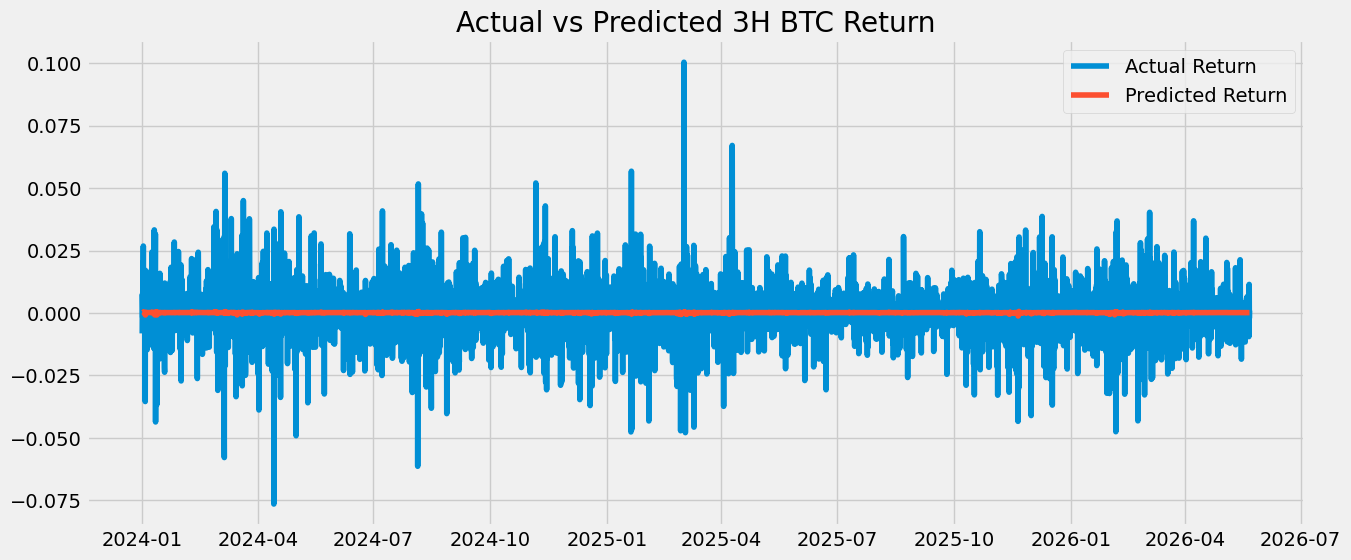

In [556]:
plt.figure(figsize=(14,6))
plt.plot(results["actual_return"], label="Actual Return")
plt.plot(results["predicted_return"], label="Predicted Return")
plt.title("Actual vs Predicted 3H BTC Return")
plt.legend()
plt.show()

##### Create Trading Signals

In [557]:
threshold = 0.001   # 0.1% predicted move filter

results["signal"] = 0

results.loc[results["predicted_return"] > threshold, "signal"] = 1
results.loc[results["predicted_return"] < -threshold, "signal"] = -1

##### Simple Strategy Return

In [558]:
results["strategy_return"] = results["signal"] * results["actual_return"]

# optional trading fee
fee = 0.0004   # 0.04%

results["trade"] = results["signal"].diff().abs()
results["strategy_return_after_fee"] = (
    results["strategy_return"] - results["trade"] * fee
)

##### EQUITY CURVE

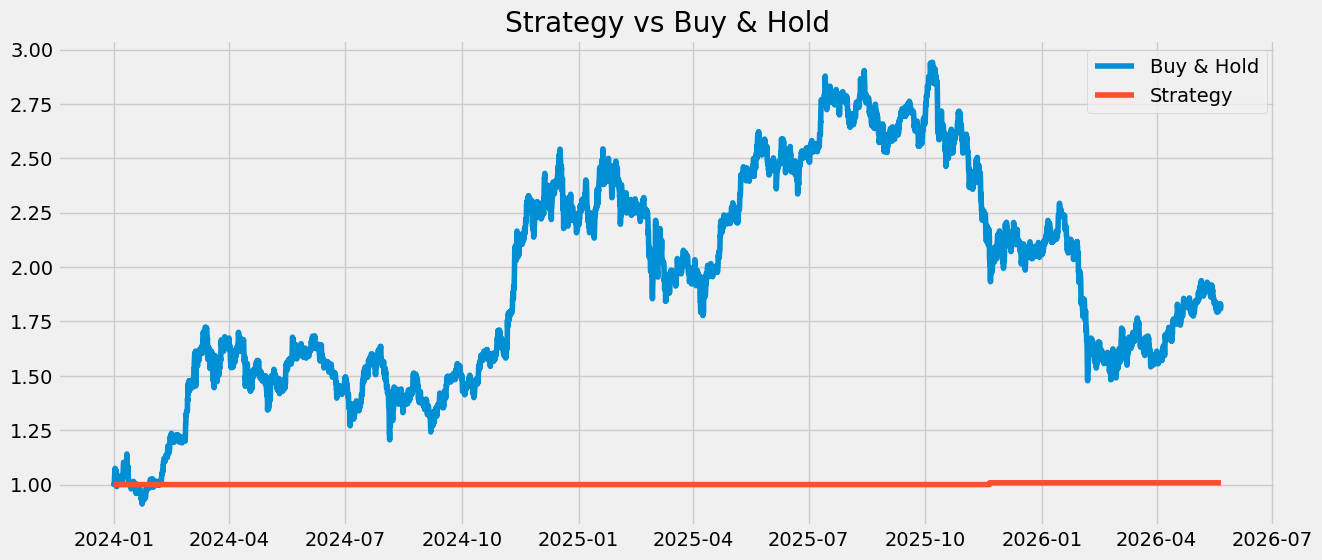

In [559]:
results["buy_hold_equity"] = np.exp(results["actual_return"].cumsum())
results["strategy_equity"] = np.exp(results["strategy_return_after_fee"].cumsum())

plt.figure(figsize=(14,6))
plt.plot(results["buy_hold_equity"], label="Buy & Hold")
plt.plot(results["strategy_equity"], label="Strategy")
plt.title("Strategy vs Buy & Hold")
plt.legend()
plt.show()


##### Backtest Metrics

In [560]:
total_return = results["strategy_equity"].iloc[-1] - 1

sharpe = (
    results["strategy_return_after_fee"].mean()
    / results["strategy_return_after_fee"].std()
) * np.sqrt(8 * 365)   # 8 candles per day for 3H data

max_drawdown = (
    results["strategy_equity"]
    / results["strategy_equity"].cummax()
    - 1
).min()

win_rate = (
    results.loc[results["signal"] != 0, "strategy_return_after_fee"] > 0
).mean()

print("Total Strategy Return:", total_return)
print("Sharpe Ratio:", sharpe)
print("Max Drawdown:", max_drawdown)
print("Win Rate:", win_rate)

Total Strategy Return: 0.008108452200713545
Sharpe Ratio: 0.6158418037862681
Max Drawdown: -0.0003999200106656886
Win Rate: 1.0


### Feature Importance

           feature  importance
34           SMA_7    0.037790
20          ema_20    0.036725
35          SMA_20    0.035823
30          RSI_21    0.034211
27     ema50_slope    0.033786
25    ema200_ratio    0.033595
23     ema20_ratio    0.032831
21          ema_50    0.031261
24     ema50_ratio    0.030937
26     ema20_slope    0.029760
8        range_pct    0.029655
11           ret_4    0.028874
33  macd_histogram    0.028781
10           ret_2    0.028269
37         SMA_100    0.027995
17       body_size    0.027901
36          SMA_50    0.027498
12           ret_8    0.026766
18      upper_wick    0.025947
29          RSI_14    0.025869
15    volume_ratio    0.025829
16   volatility_10    0.025052
31            macd    0.024980
32     macd_signal    0.024775
28           RSI_7    0.024522
22         ema_200    0.023589
19      lower_wick    0.023414
14    volume_ma_20    0.022309
13   volume_return    0.022252
7    volatility_20    0.021593
38         SMA_200    0.021198
9       

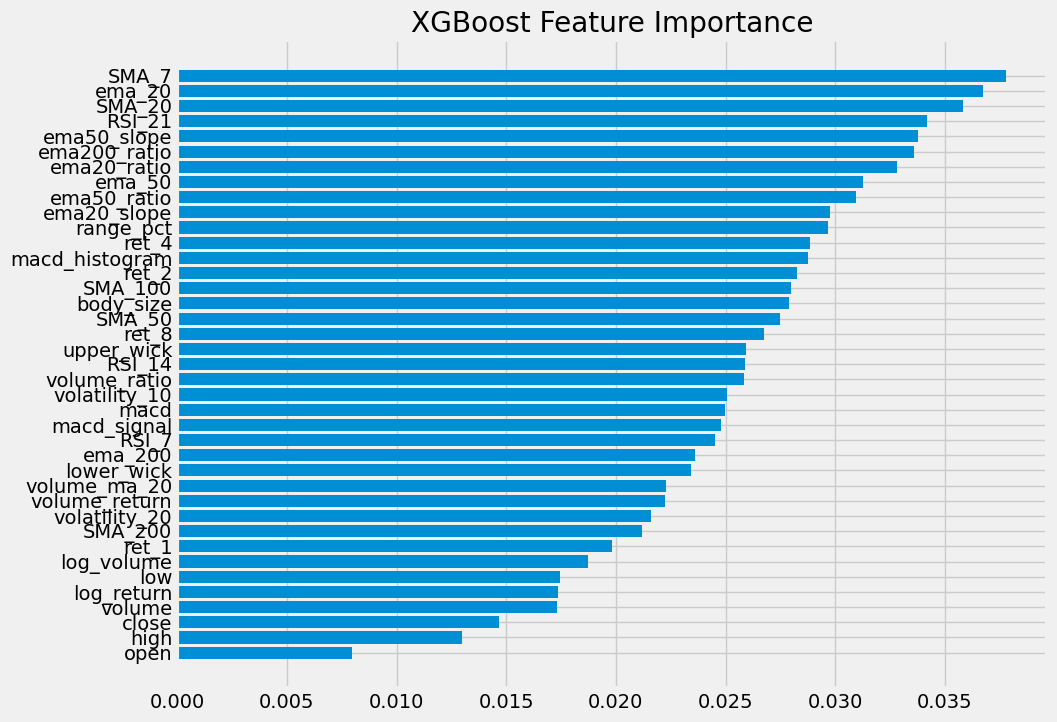

In [561]:
importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance)

plt.figure(figsize=(10,8))
plt.barh(importance["feature"], importance["importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()

In [562]:
print(results["predicted_return"].describe())
print(results["signal"].value_counts())

count    6975.000000
mean        0.000110
std         0.000072
min        -0.001222
25%         0.000102
50%         0.000121
75%         0.000137
max         0.000610
Name: predicted_return, dtype: float64
signal
 0    6974
-1       1
Name: count, dtype: int64


In [563]:
df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'log_return', 'log_volume',
       'volatility_20', 'range_pct', 'ret_1', 'ret_2', 'ret_4', 'ret_8',
       'volume_return', 'volume_ma_20', 'volume_ratio', 'volatility_10',
       'body_size', 'upper_wick', 'lower_wick', 'ema_20', 'ema_50', 'ema_200',
       'ema20_ratio', 'ema50_ratio', 'ema200_ratio', 'ema20_slope',
       'ema50_slope', 'RSI_7', 'RSI_14', 'RSI_21', 'macd', 'macd_signal',
       'macd_histogram', 'SMA_7', 'SMA_20', 'SMA_50', 'SMA_100', 'SMA_200',
       'target_3h'],
      dtype='str')

In [564]:
def create_lag_features(df, variables, lag_steps=1):
    lagged_df = df.copy()  # Create a copy of the DataFrame to avoid modifying the original
    for var in variables:
        for i in range(1, lag_steps + 1):
            lagged_df[f'lag_{var}_{i}'] = df[var].shift(i)
    return lagged_df

In [565]:
# Define variables and lag steps
variables = ['log_return', 'log_volume',
       'volatility_20', 'range_pct', 'ret_1', 'ret_2', 'ret_4', 'ret_8',
       'volume_return', 'volume_ma_20', 'volume_ratio', 'volatility_10',
       'body_size', 'upper_wick', 'lower_wick', 'ema_20', 'ema_50', 'ema_200',
       'ema20_ratio', 'ema50_ratio', 'ema200_ratio', 'ema20_slope',
       'ema50_slope', 'RSI_14', 'macd', 'macd_signal', 'macd_histogram',]
lag_steps = 12  # Number of lag steps want to create

# Create lag features
lagged_features_df = create_lag_features(df, variables, lag_steps)

# Check shape of the new dataframe
print(lagged_features_df.shape)

(18460, 364)


In [566]:
lagged_features_df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'log_return', 'log_volume',
       'volatility_20', 'range_pct', 'ret_1',
       ...
       'lag_macd_histogram_3', 'lag_macd_histogram_4', 'lag_macd_histogram_5',
       'lag_macd_histogram_6', 'lag_macd_histogram_7', 'lag_macd_histogram_8',
       'lag_macd_histogram_9', 'lag_macd_histogram_10',
       'lag_macd_histogram_11', 'lag_macd_histogram_12'],
      dtype='str', length=364)

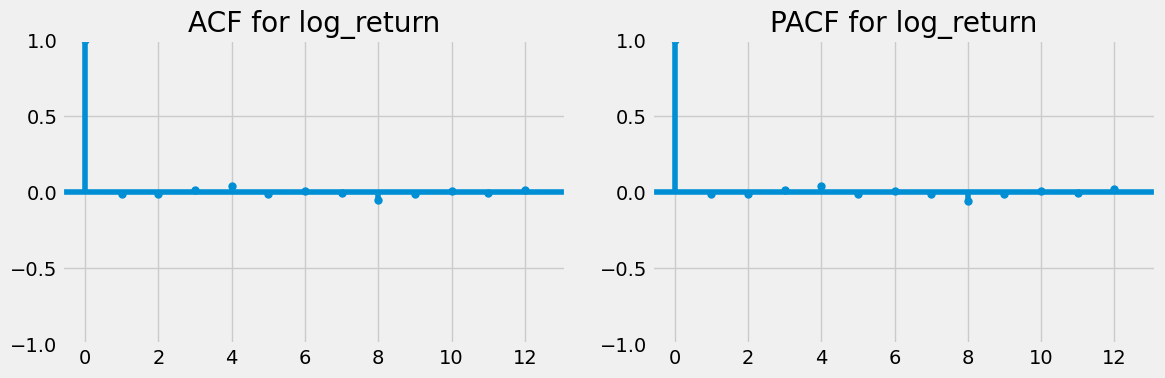

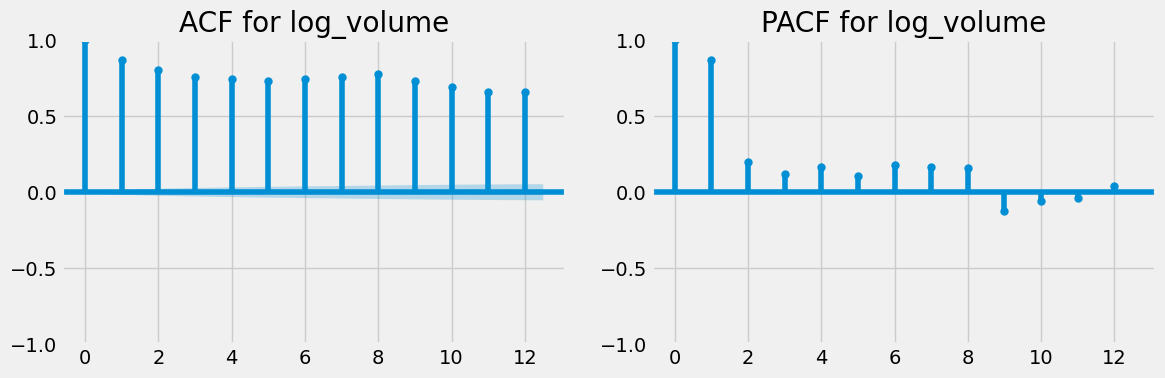

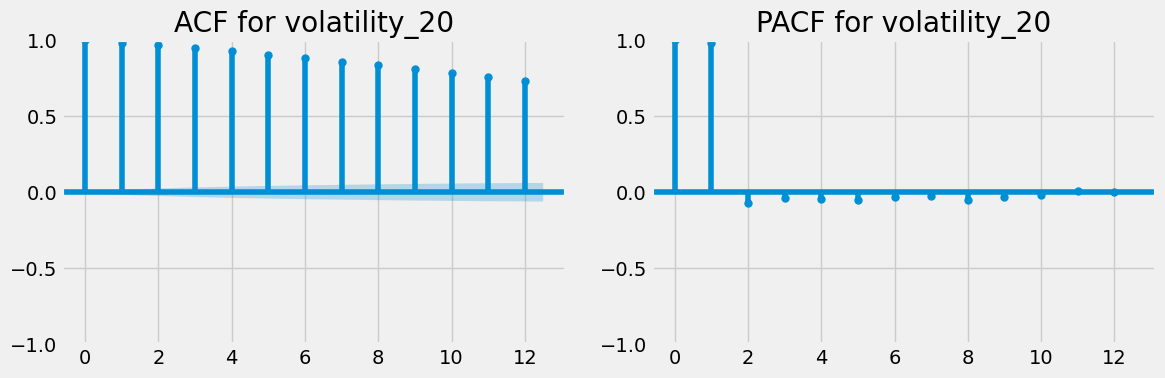

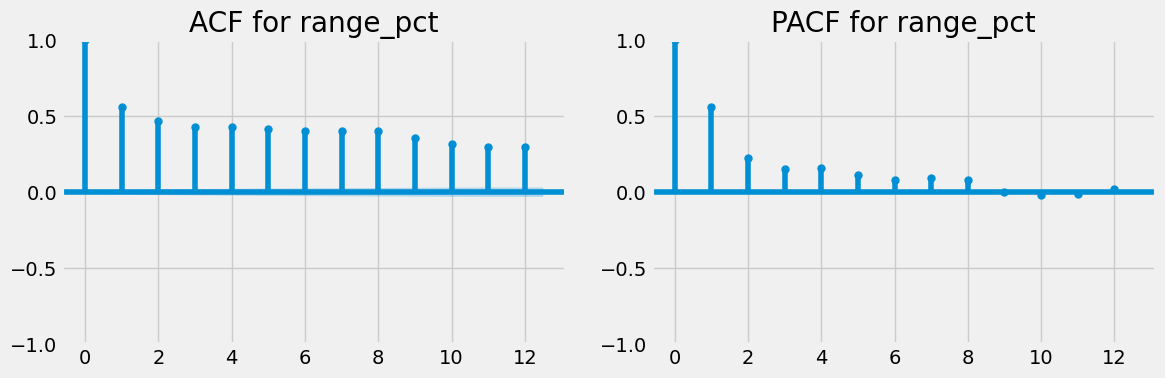

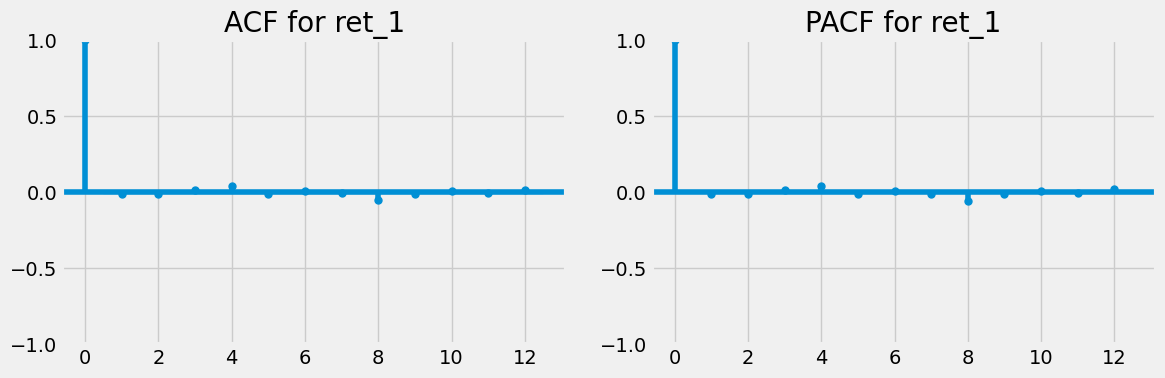

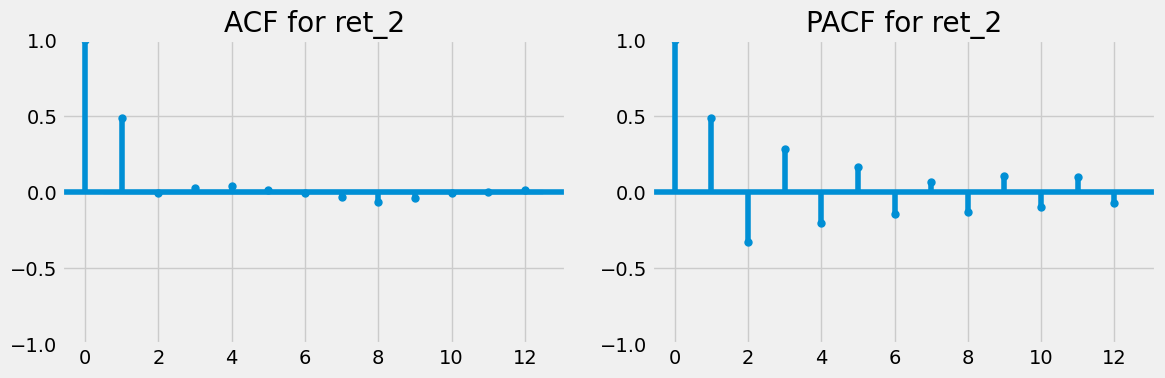

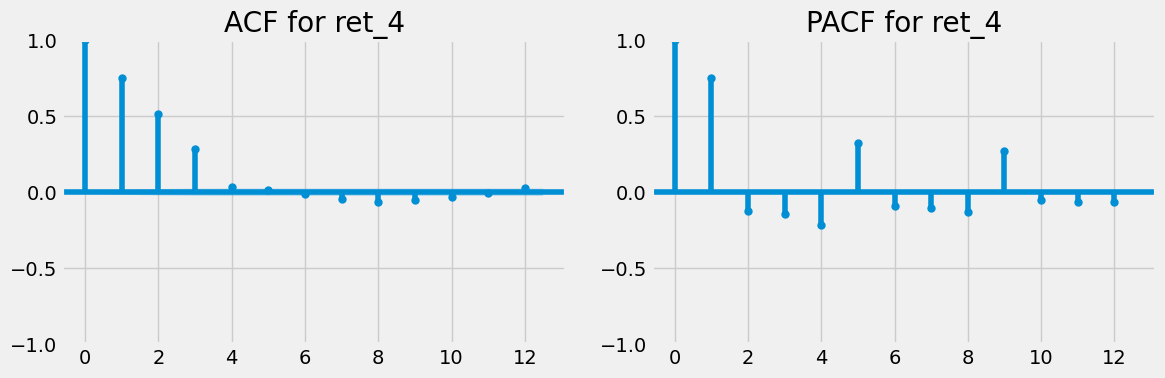

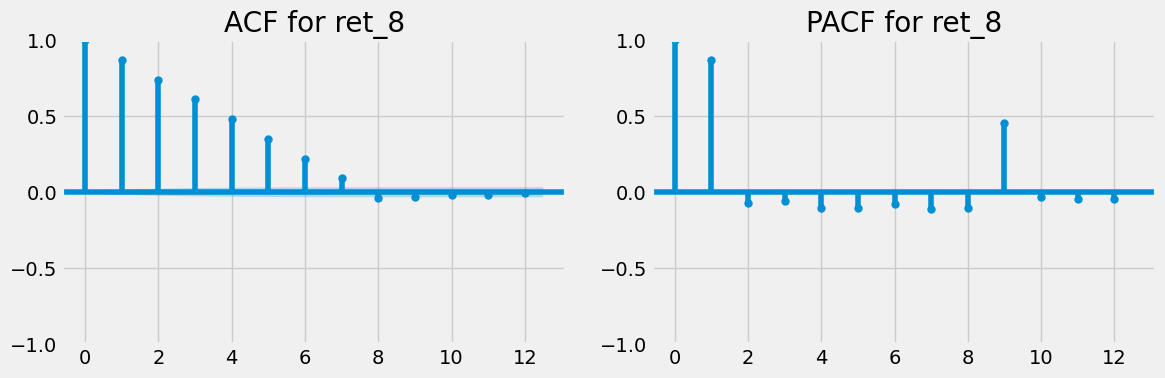

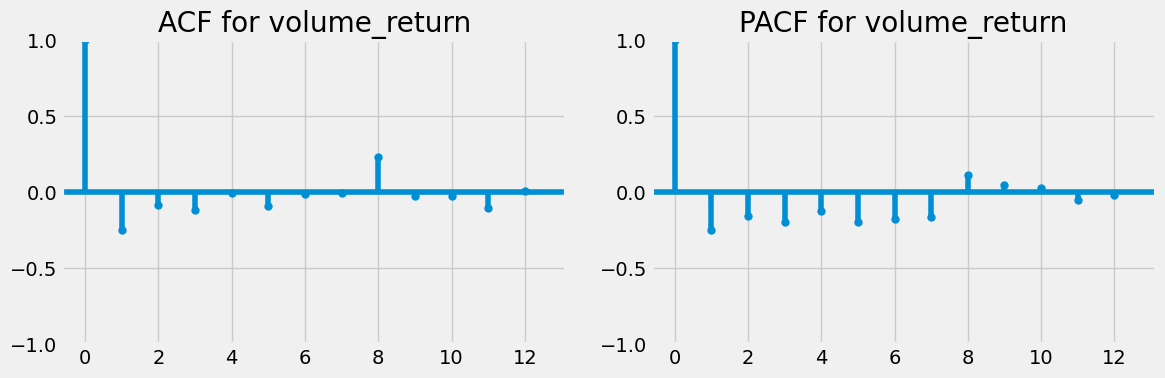

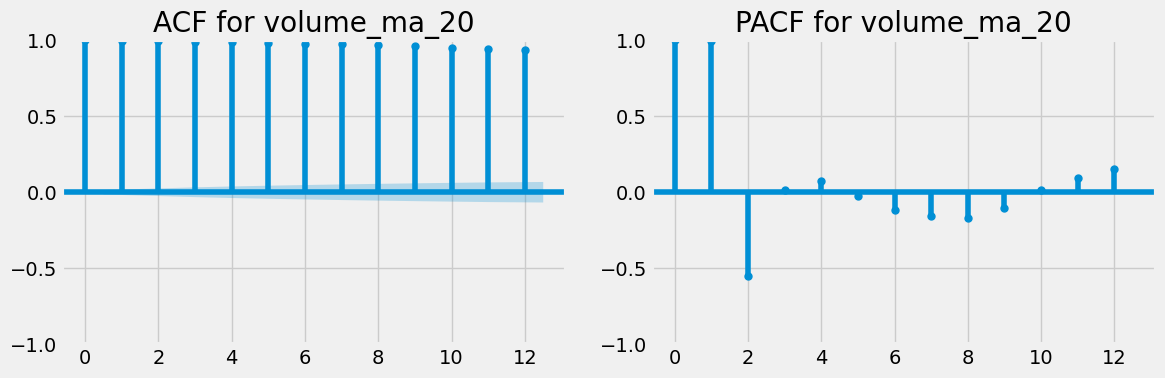

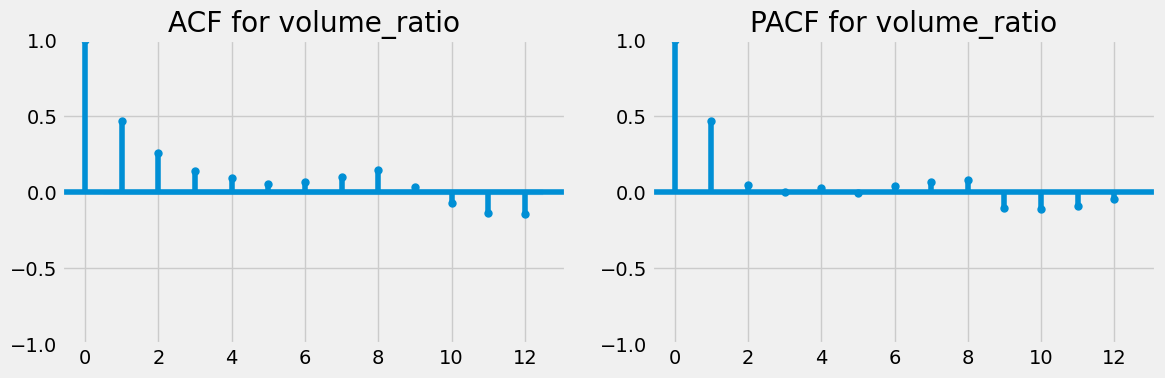

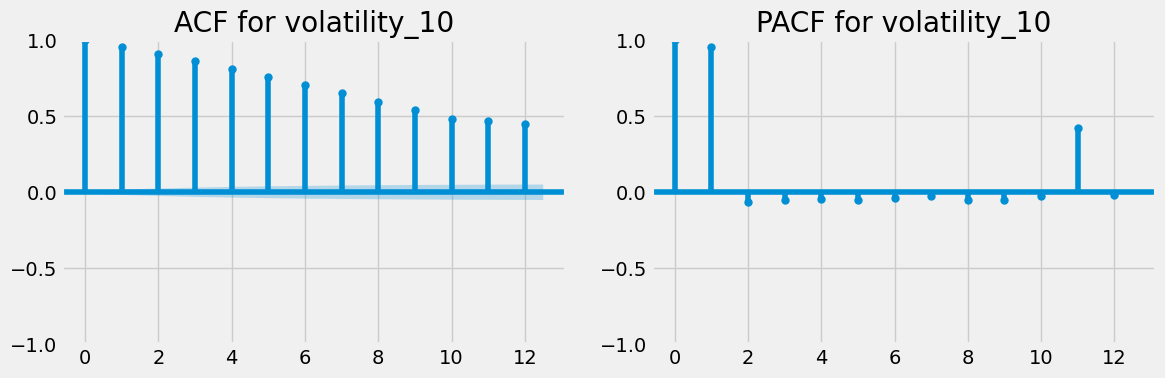

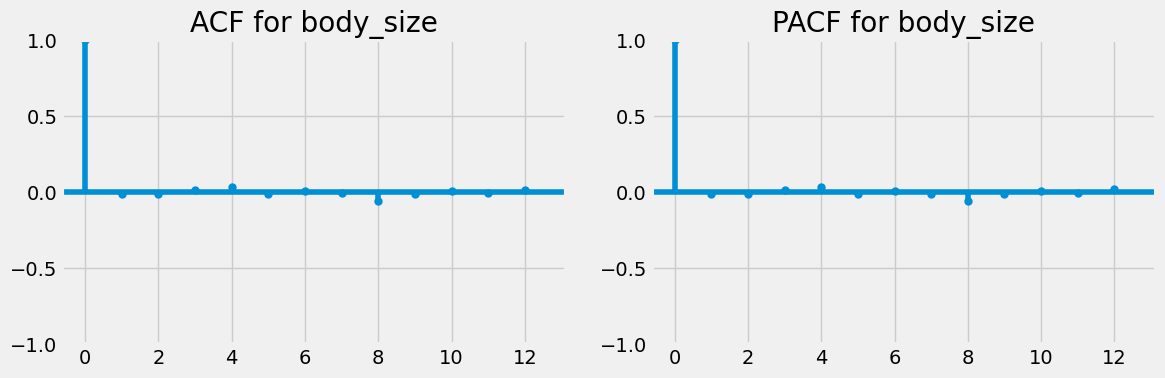

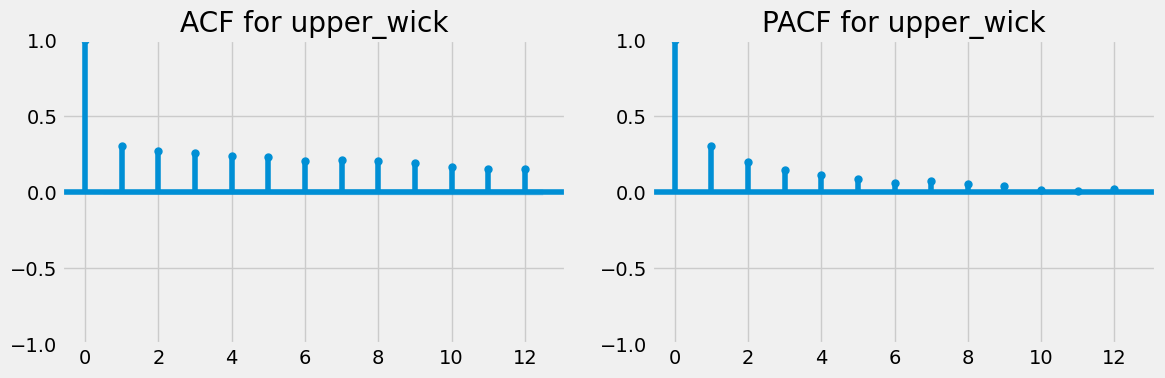

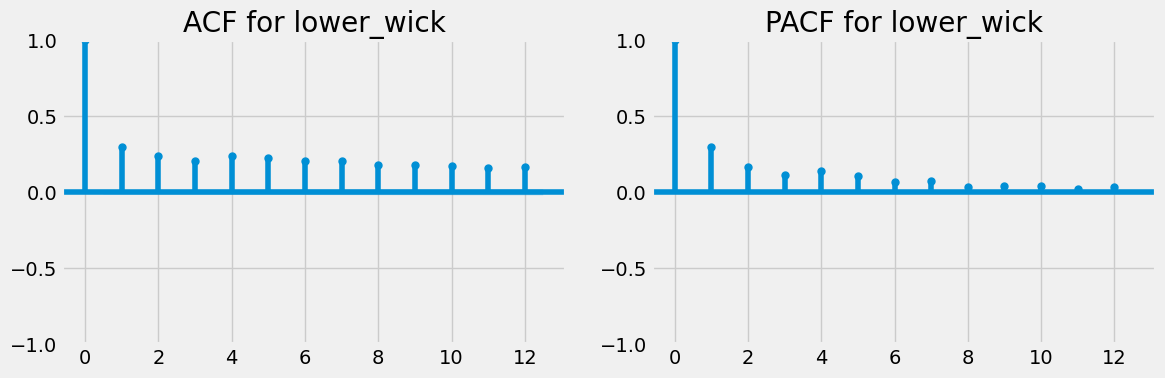

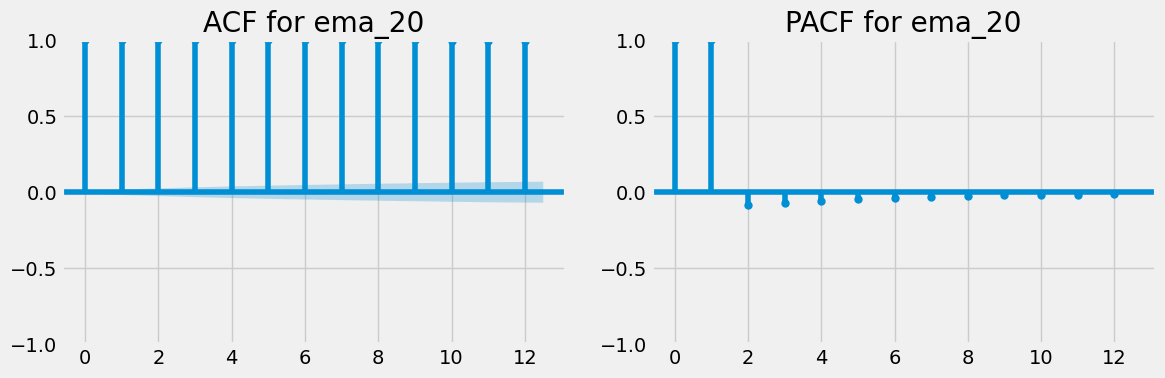

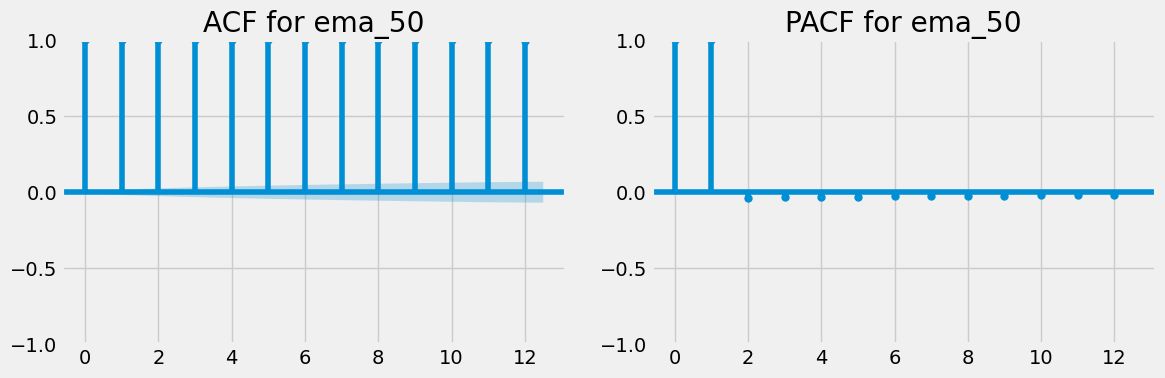

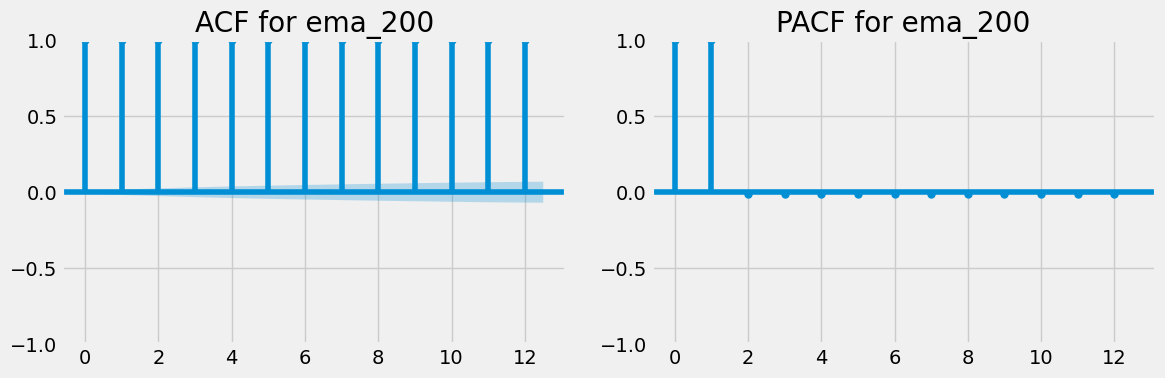

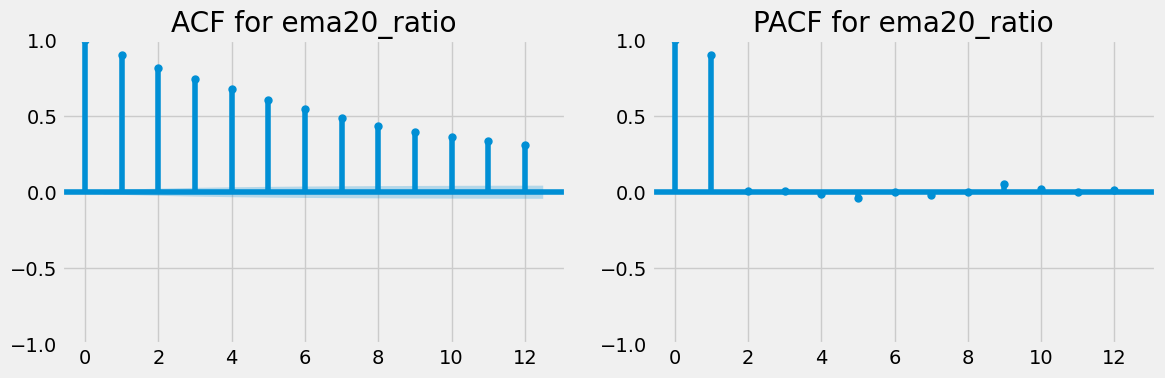

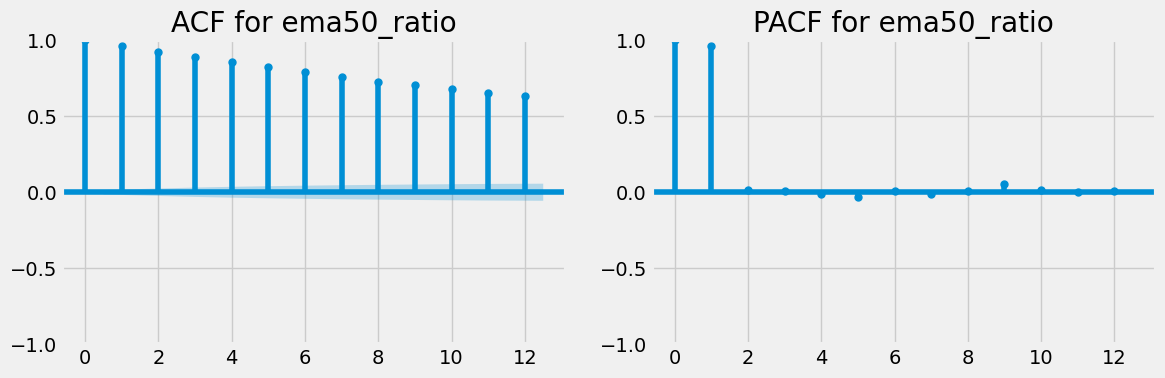

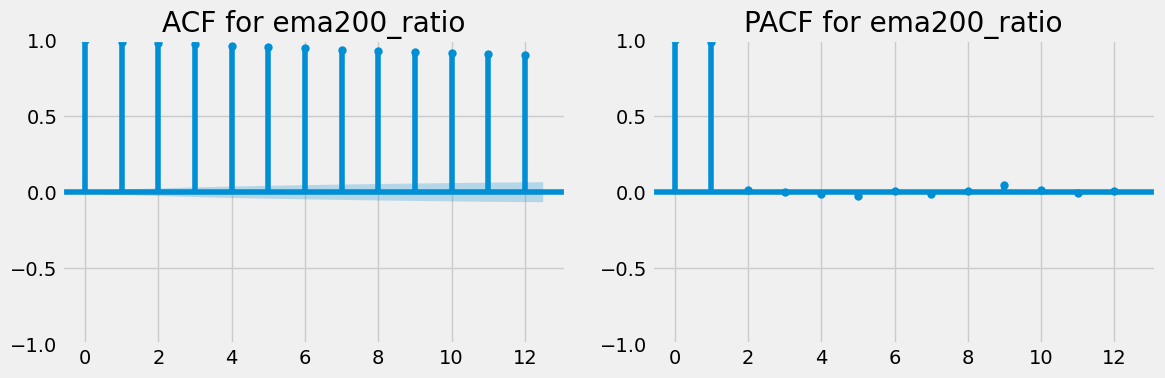

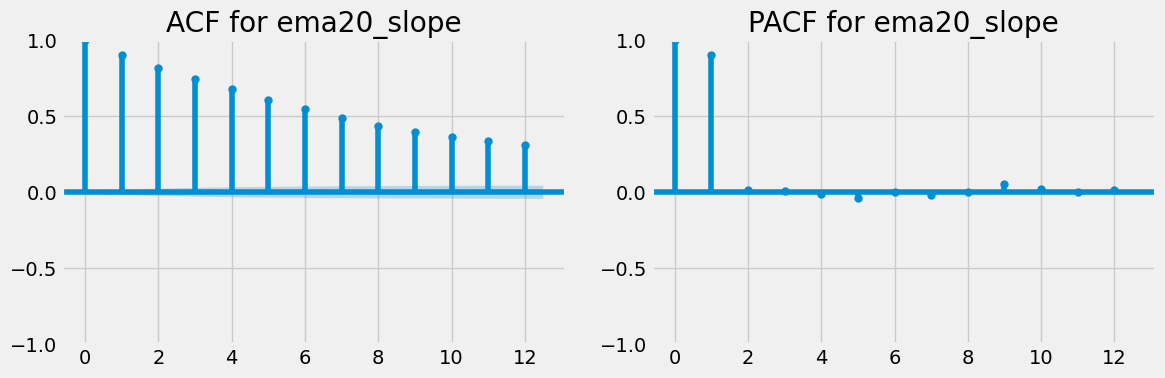

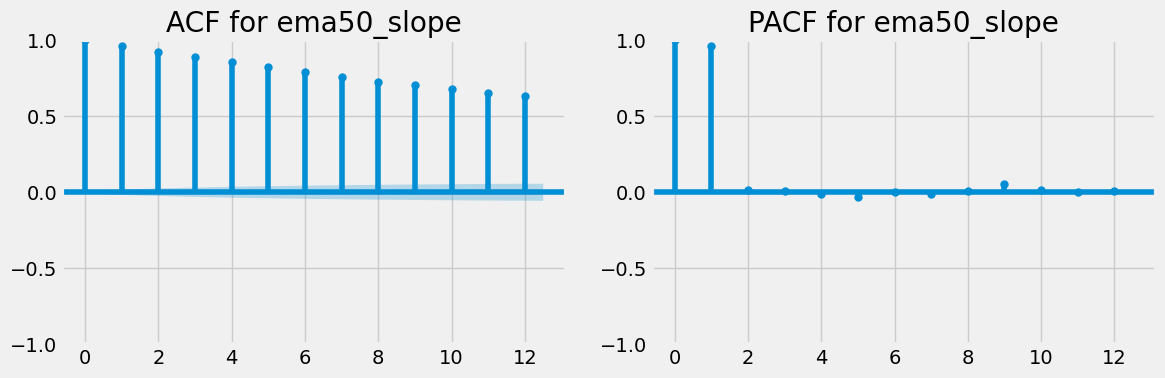

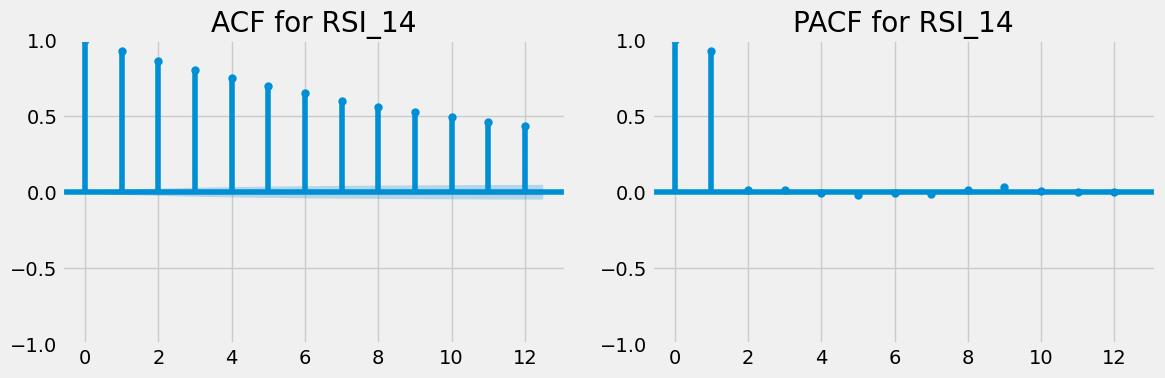

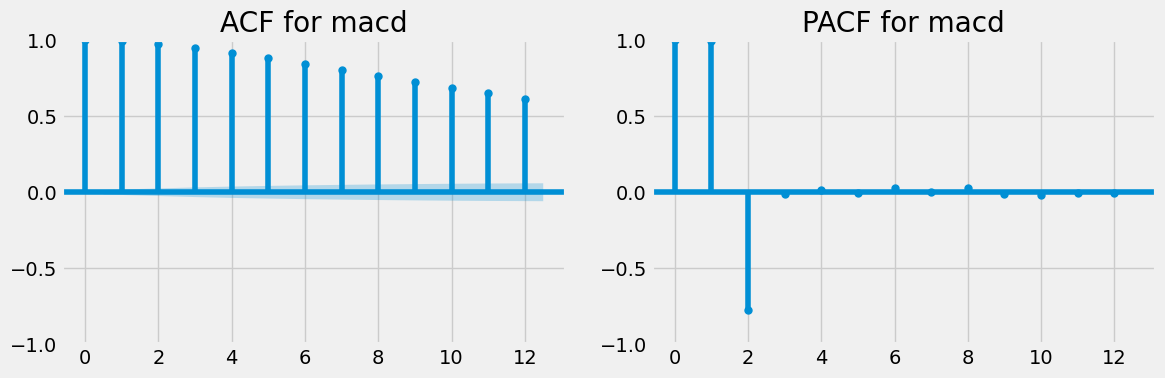

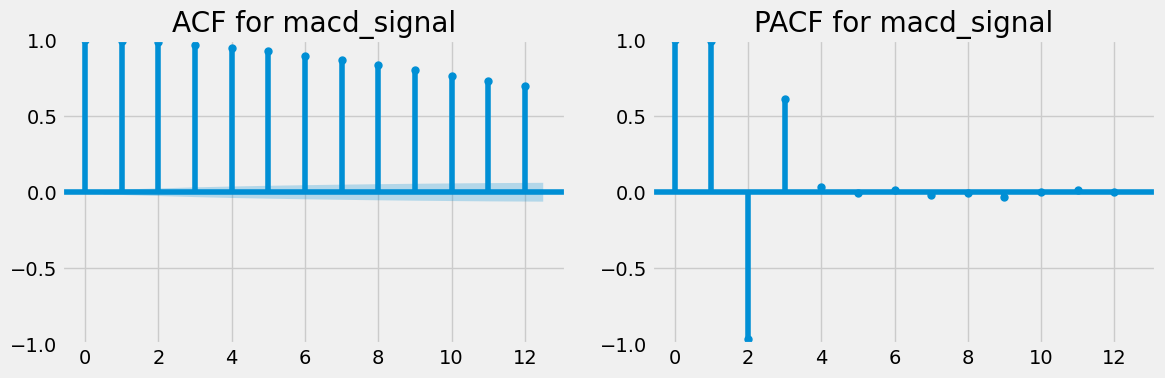

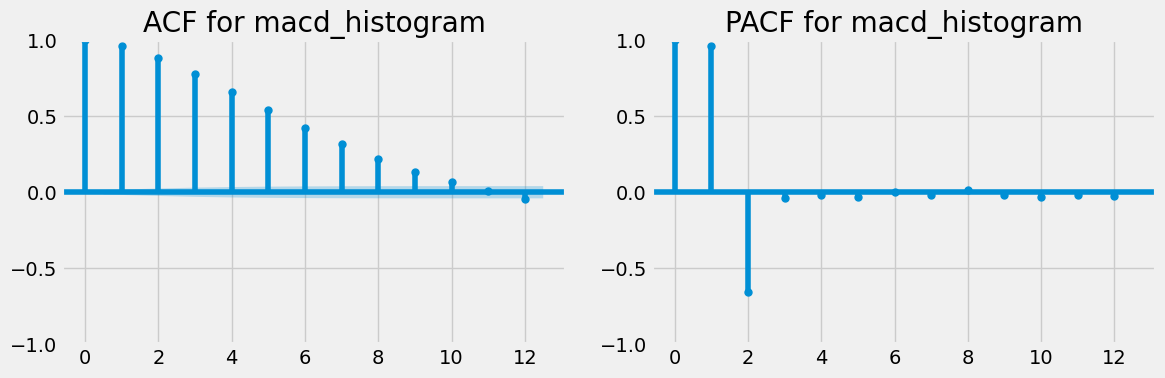

In [567]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for each variable
for variable in variables:
    # Create subplots for each variable
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    
    # Plot ACF
    plot_acf(lagged_features_df[variable], lags=12, ax=axes[0])
    axes[0].set_title(f'ACF for {variable}')
    
    # Plot PACF
    plot_pacf(lagged_features_df[variable], lags=12, ax=axes[1])
    axes[1].set_title(f'PACF for {variable}')
    
    # Adjust layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()